In [3]:
import ee
import geemap
import geopandas as gpd
ee.Authenticate()
ee.Initialize(project = 'ee-debrajkolya')


# Load AOI
shp = gpd.read_file(r"D:\Google Earth Engine\West bengal\District_shape_West_Bengal.shp")
birbhum = shp[shp['NAME'] == 'Birbhum']
aoi = geemap.geopandas_to_ee(birbhum)
Map = geemap.Map()

# Load Teraclimate data
terraclimate = (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate('2015-01-01', '2025-12-31')
    .filterBounds(aoi)
    .mean()
    .clip(aoi.geometry())
    )

# Extract variables
tmin = terraclimate.select('tmmn')
tmax = terraclimate.select('tmmx')
vap = terraclimate.select('vap')

# Scale factor
tmin = tmin.multiply(0.1)
tmax = tmax.multiply(0.1)
vap = vap.multiply(0.001)

# Mean temperature
tmean = (
    tmin.add(tmax)
    .divide(2)
    .rename("Temperature")
)

# Calulate saturation vapor pressure (es) using Tetens formula
es = (
    tmean.expression(
    '0.6108*exp((17.27*T)/(T+237.3))',
    {'T': tmean}
    )
)

# Calculate Relative Humidity (RH)
rh = (
    vap.divide(es)
    .multiply(100)
    .rename("Relative Humidity")
)

# visualization
vis_temp = {
    'min': tmean.reduceRegion(ee.Reducer.min(), aoi.geometry(), 1000).get("Temperature").getInfo(),
    'max': tmean.reduceRegion(ee.Reducer.max(), aoi.geometry(), 1000).get("Temperature").getInfo(),
    'palette': ['#4400ff', '#00ffea', '#fbff00', '#ff0000']
    }

vis_rh = {
    'min': rh.reduceRegion(ee.Reducer.min(), aoi.geometry(), 1000).get("Relative Humidity").getInfo(),
    'max': rh.reduceRegion(ee.Reducer.max(), aoi.geometry(), 1000).get("Relative Humidity").getInfo(),
'palette':['#ffffff', '#0033ff', '#00ff62']
}

# Temp legend
temp_legend = {
    "Very Low": "#4400ff",
    "Low": "#00ffea",
    "Moderate": "#fbff00",
    "High": "#ff0000",
}

# Map.add_legend(
#     title="Temperature (°C)",
#     legend_dict=temp_legend,
#     position="bottomright"
# )

# Relative Humidity Legend
rh_legend = {
    "Low": "#ffffff",
    "Moderate": "#0033ff",
    "High": "#00ff62",
}

Map.add_legend(
    title="Relative Humidity (%)",
    legend_dict=rh_legend,
    position="bottomright"
)

# Layers add
Map.addLayer(aoi,{}, 'Birbhum')
Map.centerObject(aoi, 9)
Map.addLayer(tmean, vis_temp, 'Mean Temperature')
Map.addLayer(rh, vis_rh, 'Relative Humidity')
Map


Map(center=[23.9514124185984, 87.66127324621127], controls=(WidgetControl(options=['position', 'transparent_bg…

   Relative Humidity  Temperature
0          70.419092    26.658333
1          70.642347    26.648333
2          70.825104    26.645417
3          69.504816    26.608333
4          69.943294    26.678333


Correlation Coefficient (r): -0.8386

Relationship: Strong Negative Correlation 

P-value: 2.185233646950539e-63

Coefficient of Determination (r²) : 0.7031767297479805



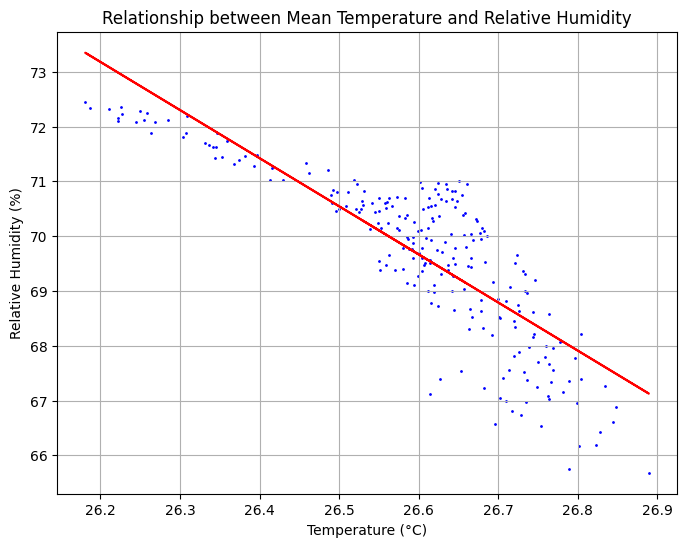

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# Combine both bands into one image
temperature = tmean.rename("Temperature")
humidity = rh.rename("Relative Humidity")

combined = temperature.addBands(humidity)

# Create random sample points
samples =combined.sample(
    region=aoi,
    scale = 4638,
    numPixels = 1000,
    geometries=True
)

# convert to data frame
features = samples.getInfo()["features"]

rows = [f["properties"] for f in features]

df = pd.DataFrame(rows)

# print sample table
print(df.head())

# Calculate Linear Regression
X = df[['Temperature']]
Y = df['Relative Humidity']

model = LinearRegression()
model.fit(X, Y)

# Prediction
prediction = model.predict(X)

# Calculate Pearson correlation coefficient
r, p = pearsonr(
    df['Temperature'],
    df['Relative Humidity']
)

# Interpretation
if abs(r) < 0.30:
    strength = "Weak"
elif abs(r) < 0.70:
    strength = "Moderate"
else:
    strength = "Strong"

direction = "Positive" if r > 0 else "Negative"

print("\n")
print(f"Correlation Coefficient (r): {r:.4f}\n")
print(f"Relationship: {strength} {direction} Correlation \n")
print(f"P-value: {p}\n")

# Scatter plot
plt.figure(figsize = (8, 6))

plt.scatter(
    df['Temperature'],
    df['Relative Humidity'],
    color='blue',
    s=1
)

# Add regression line
plt.plot(
    df['Temperature'],
    prediction,
    color = 'red'
)

# Calculate Coefficient of Determination (R²)
r2 = model.score(X,Y)

print(f"Coefficient of Determination (r²) : {r2}\n")

plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Relationship between Mean Temperature and Relative Humidity')
plt.grid(True)

plt.show()

# Export dataframe to csv
df.to_csv(
    "D:/Google Earth Engine/GEE_MAP_Python/ee-debrajkolya/Relationship Tempareture & relative humidity/Output/data.csv",
    index = False
)

